# Fixed vs redrawn MSD trial: the L=32 sample-count study

Loads and plots the runs comparing `sampled_msd_cpmc.py` (trial drawn once, **fixed**) with `resampled_msd_cpmc.py` (trial **redrawn every step**) at L=32, for N = 5000, 10000 and 20000 samples.

All runs use L=32 at half filling, U=4, a χ=8 DMRG trial, IS coefficients, 200 walkers, 100 equilibration + 200 sampling blocks of 20 steps, dt=0.01, and the same seeds. Each N ran as a fixed/resampled pair side by side.

Data, in `msd_study_data/`:

- **`results.jsonl`:** one record per finished run. It holds `L, N, chi, method, e_cpmc, err_cpmc, t_run`, and under `raw` the script's own JSON record. Runs started after per-block saving also carry `raw['block_energies']` and `raw['block_weights']`, laid out as [initial estimate, `n_eql` equilibration blocks, sampling blocks].
- **`{method}_L32*.log`:** the run logs. The N=5000 runs predate per-block saving, so for them only trot's 20-block progress lines exist. Runs still in progress are also read from their logs.

To refresh the data after new runs finish, copy `results.jsonl` and the logs again from the runners' directory (see `run_cmp*.py`).

In [11]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

DATA = Path("msd_study_data")
L = 32
NS = [5000, 10000,20000]
METHODS = ["fixed", "resampled"]
E_EXACT = {8: -4.235806999129424, 16: -8.818767450711654,        # L=8: FCI; others: DMRG chi=200
           24: -13.406070927828882, 32: -17.9945781596172}
TAU_BLOCK = 20 * 0.01                                            # N_PROP * dt: imaginary time per block

LABEL = {"fixed": "fixed trial", "resampled": "redrawn every step"}
COLOR = {"fixed": "#2a78d6", "resampled": "#eb6834"}             # categorical slots 1, 2
INK2, GRID = "#52514e", "#e4e3df"
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11, "axes.grid": True,
                     "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False})

## Loading

In [12]:
def log_path(method, N, L=L):
    return DATA / (f"{method}_L{L}.log" if N == 5000 else f"{method}_L{L}_N{N}.log")


def read_log(path):
    # trot's progress lines, one every 20 blocks.
    #   eql: (block, chunk-average energy, total weight)
    #   smp: (block, running mean, running error, chunk-average energy, total weight)
    eql, smp = [], []
    if not path.exists():
        return dict(eql=np.zeros((0, 3)), smp=np.zeros((0, 5)))
    for line in open(path):
        m = re.match(r"\[eql\s+(\d+)/\d+\]\s+(\S+)\s+(\S+)", line)
        if m:
            eql.append([float(g) for g in m.groups()])
        m = re.match(r"\[blk\s+(\d+)/\d+\]\s+(\S+)\s+(\S+)\s+(\S+)\s+(\S+)", line)
        if m:
            smp.append([float(g) for g in m.groups()])
    return dict(eql=np.array(eql).reshape(-1, 3), smp=np.array(smp).reshape(-1, 5))


def get_run(method, N, results, L=L, chi=8, log=None):
    # everything known about one run: final numbers if it finished, per-block arrays if it saved
    # them, and the log's 20-block chunks either way
    rec = results.get((L, N, chi, method))
    run = dict(method=method, N=N, L=L, finished=rec is not None, log=read_log(log or log_path(method, N, L)))
    if rec is not None:
        raw = rec["raw"]
        run.update(e=rec["e_cpmc"], err=rec["err_cpmc"], t_run=rec["t_run"])
        if "block_energies" in raw:
            run["blocks"] = dict(e=np.array(raw["block_energies"]), w=np.array(raw["block_weights"]),
                                 n_eql=raw["n_eql"])
    elif len(run["log"]["smp"]):                                   # still running
        last = run["log"]["smp"][-1]
        run.update(e=last[1], err=last[2], sampled=int(last[0]))
    return run


results = {(r["L"], r.get("N", 5000), r.get("chi", 8), r["method"]): r
           for r in map(json.loads, open(DATA / "results.jsonl")) if r.get("seed", 0) == 0}
E_TRIAL = next(r["e_dmrg_trial"] for k, r in results.items() if k[0] == L and k[2] == 8)
runs = {(m, N): get_run(m, N, results) for m in METHODS for N in NS}
print(f"loaded {len(results)} finished runs; chi=8 trial energy at L={L}: {E_TRIAL:.6f}, exact {E_EXACT[L]:.6f}")

loaded 19 finished runs; chi=8 trial energy at L=32: -17.848936, exact -17.994578


## Summary

In [13]:
print(f"{'N':>6}  {'method':10s} {'E':>11s} {'err':>7s} {'E - exact':>10s} {'z':>6s} {'t_run [h]':>9s}  status")
for N in NS:
    for m in METHODS:
        r = runs[m, N]
        if "e" not in r:
            print(f"{N:>6}  {m:10s} {'':>47s}  not started")
            continue
        bias = r["e"] - E_EXACT[L]
        status = "done" if r["finished"] else f"running: {r['sampled']}/200 sampling blocks"
        t_run = f"{r['t_run'] / 3600:9.2f}" if r["finished"] else " " * 9
        print(f"{N:>6}  {m:10s} {r['e']:11.5f} {r['err']:7.4f} {bias:+10.4f} {bias / r['err']:+6.1f} {t_run}  {status}")

     N  method               E     err  E - exact      z t_run [h]  status
  5000  fixed        -17.65284  0.0651    +0.3417   +5.2      1.58  done
  5000  resampled    -18.30540  0.0992    -0.3108   -3.1      1.79  done
 10000  fixed        -17.75744  0.0664    +0.2371   +3.6      3.69  done
 10000  resampled    -18.15364  0.0839    -0.1591   -1.9      3.83  done
 20000  fixed        -17.80050  0.0492    +0.1941   +3.9     12.71  done
 20000  resampled    -18.14249  0.0765    -0.1479   -1.9     13.44  done


## Energy vs number of samples

The final energy of each run, with its blocking error. Open markers are runs still in progress, taken from their running estimate.

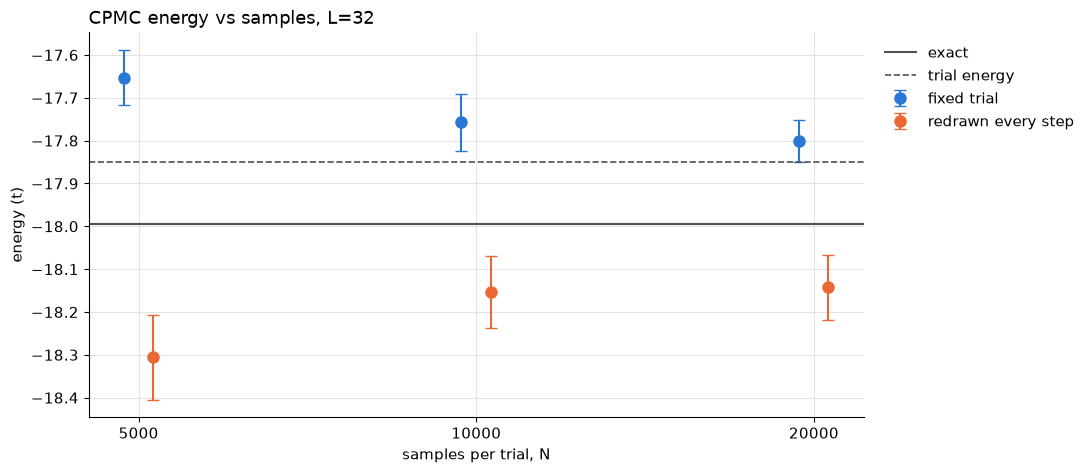

In [14]:
def plot_vs_N(runs=runs, ns=NS, L=L, e_trial=E_TRIAL, ax=None):
    ax = ax or plt.subplots()[1]
    for k, m in enumerate(METHODS):
        for N in ns:
            r = runs[m, N]
            if "e" not in r:
                continue
            x = N * (1 + 0.03 * (2 * k - 1))                         # small offset so bars don't overlap
            ax.errorbar(x, r["e"], r["err"], fmt="o", ms=8, color=COLOR[m], capsize=4,
                        mfc=COLOR[m] if r["finished"] else "white",
                        label=LABEL[m] if N == ns[0] else None)
    ax.axhline(E_EXACT[L], color=INK2, lw=1.5, label="exact")
    ax.axhline(e_trial, color=INK2, lw=1.2, ls="--", label="trial energy")
    ax.set_xscale("log")
    ax.minorticks_off()
    ax.set_xticks(ns, [str(N) for N in ns])
    ax.set_xlabel("samples per trial, N")
    ax.set_ylabel("energy (t)")
    ax.set_title(f"CPMC energy vs samples, L={L}", loc="left")
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
    return ax


plot_vs_N();

## Energy per block vs imaginary time

One point per block, with the running (weighted) mean over the sampling phase and the final mean ± error. For runs without per-block data (N=5000), the log's 20-block averages are plotted instead.

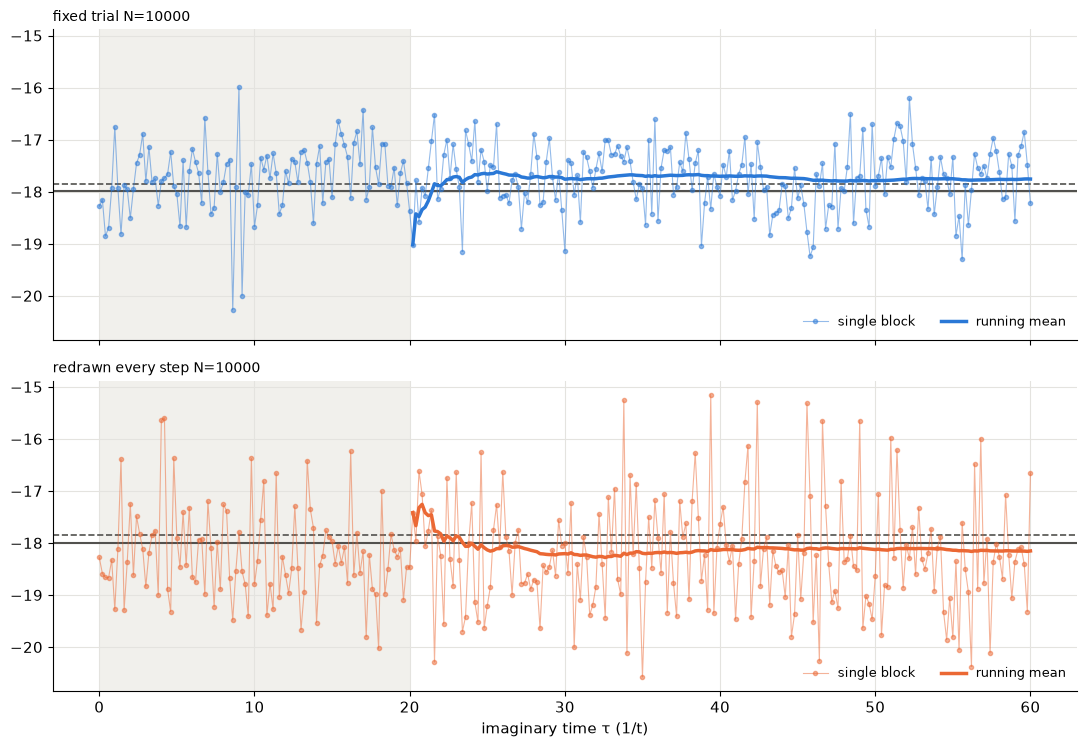

In [15]:
def plot_blocks(N, methods=METHODS, show_running=True, runs=runs, L=L, e_trial=E_TRIAL):
    fig, axes = plt.subplots(len(methods), 1, figsize=(11, 3.8 * len(methods)), sharex=True, sharey=True,
                             squeeze=False)
    for ax, m in zip(axes[:, 0], methods):
        r = runs[m, N]
        ax.axhline(E_EXACT[L], color=INK2, lw=1.5)
        ax.axhline(e_trial, color=INK2, lw=1.2, ls="--")
        if "blocks" in r:
            b = r["blocks"]
            tau = np.arange(len(b["e"])) * TAU_BLOCK
            s = slice(1 + b["n_eql"], None)
            ax.plot(tau, b["e"], "-o", color=COLOR[m], lw=0.8, ms=3, alpha=0.5, label="single block")
            if show_running:
                run_mean = np.cumsum(b["w"][s] * b["e"][s]) / np.cumsum(b["w"][s])
                ax.plot(tau[s], run_mean, color=COLOR[m], lw=2.5, label="running mean")
            ax.axvspan(0, b["n_eql"] * TAU_BLOCK, color="#f1f0ec", lw=0, zorder=0)
        else:                                                          # 20-block chunk averages from the log
            lg = r["log"]
            n_eql = lg["eql"][-1, 0] if len(lg["eql"]) else 0
            blk = np.r_[lg["eql"][:, 0], n_eql + lg["smp"][:, 0]]
            e = np.r_[lg["eql"][:, 1], lg["smp"][:, 3]]
            ax.plot(np.where(blk == 0, 0, blk - 10) * TAU_BLOCK, e, "-o", color=COLOR[m], ms=6,
                    label="20-block average")
            ax.axvspan(0, n_eql * TAU_BLOCK, color="#f1f0ec", lw=0, zorder=0)
        if "e" in r:
            state = "" if r["finished"] else f"  (running, {r['sampled']} blocks)"
        #     ax.set_title(f"{LABEL[m]}, N={N}:  {r['e']:.3f} ± {r['err']:.3f}   "
        #                  f"({r['e'] - E_EXACT[L]:+.3f} vs exact){state}", loc="left", fontsize=11)
        ax.set_title(f"{LABEL[m]} N={N}", loc="left", fontsize=10)
        # ax.set_ylabel("energy (t)")
        ax.legend(loc="lower right", frameon=False, fontsize=9, ncol=2)
    axes[-1, 0].set_xlabel("imaginary time τ (1/t)")
    fig.tight_layout()
    return fig


plot_blocks(10000);

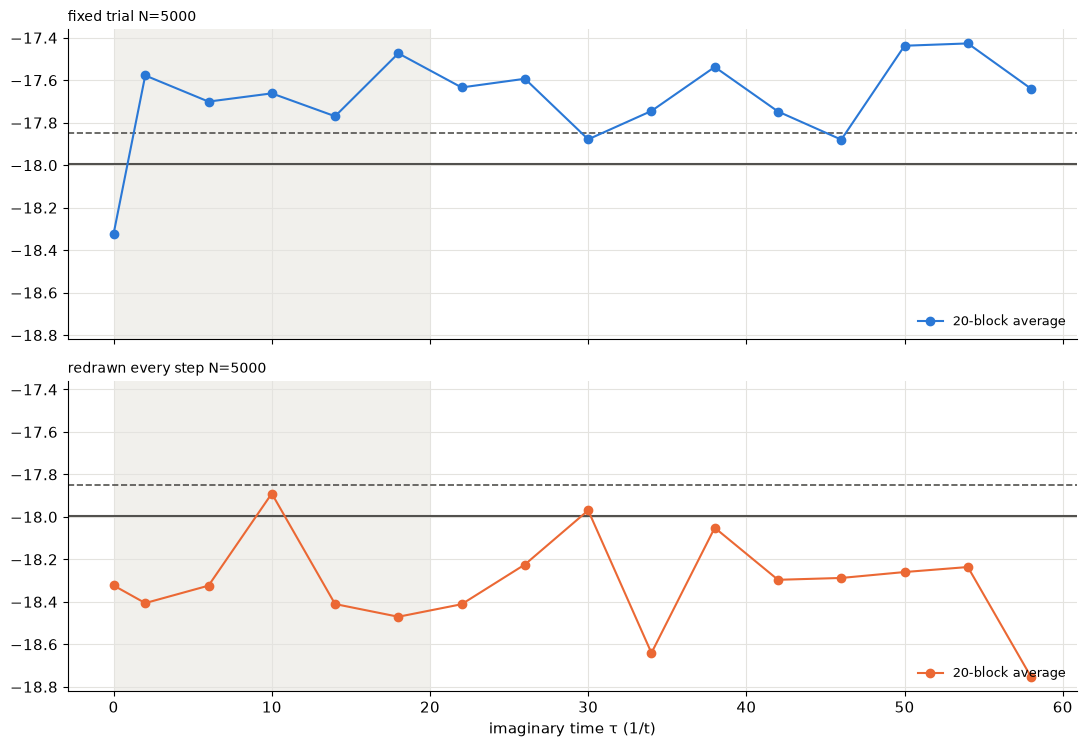

In [16]:
plot_blocks(5000);

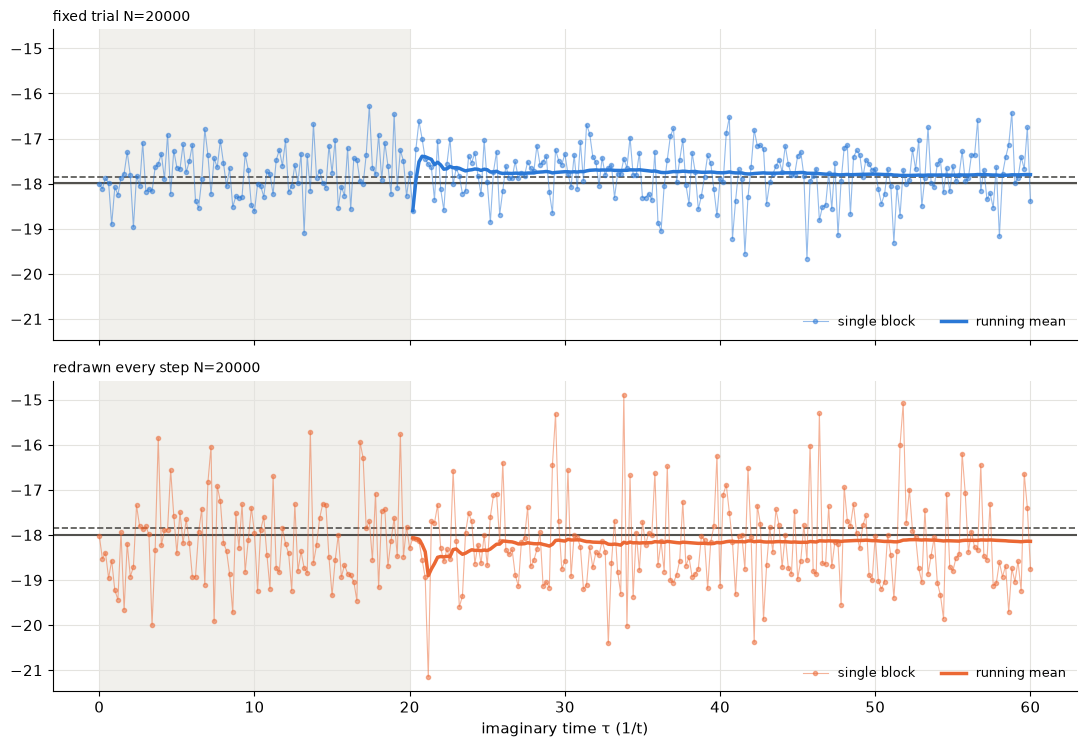

In [17]:
if ("fixed", 20000) in runs:      # add 20000 to NS to load it
    plot_blocks(20000);

## Running mean over the sampling phase, all N

Per-block runs give the running weighted mean at every block. The N=5000 runs, and runs in progress, give trot's running estimate every 20 blocks.

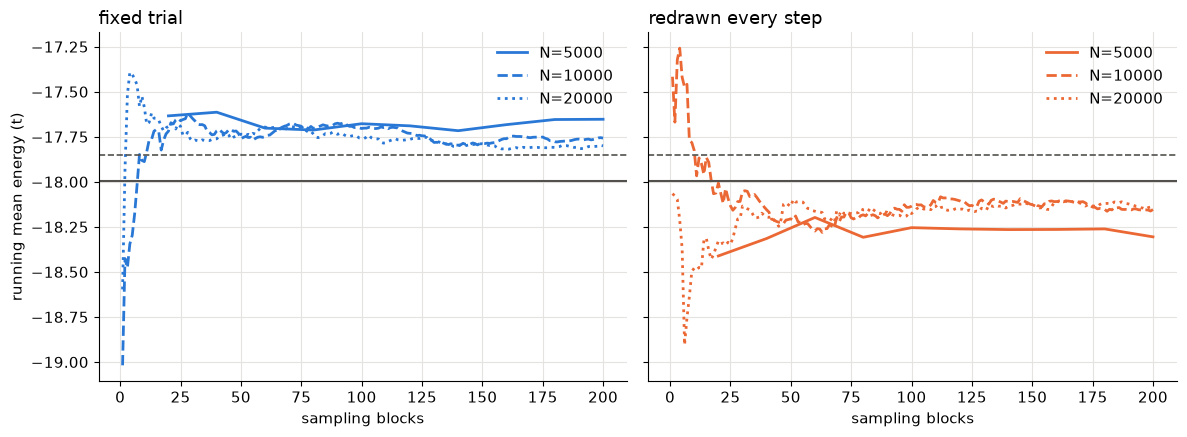

In [18]:
def running_mean(r):
    # (sampling blocks done, running mean): per block if saved, else every 20 blocks from the log
    if "blocks" in r:
        b = r["blocks"]
        s = slice(1 + b["n_eql"], None)
        return np.arange(1, len(b["e"][s]) + 1), np.cumsum(b["w"][s] * b["e"][s]) / np.cumsum(b["w"][s])
    return r["log"]["smp"][:, 0], r["log"]["smp"][:, 1]


def plot_running(methods=METHODS):
    fig, axes = plt.subplots(1, len(methods), figsize=(12, 4.5), sharey=True, squeeze=False)
    for ax, m in zip(axes[0], methods):
        for N, ls in zip(NS, ["-", "--", ":"]):
            x, y = running_mean(runs[m, N])
            if len(x):
                ax.plot(x, y, ls, color=COLOR[m], lw=2, label=f"N={N}")
        ax.axhline(E_EXACT[L], color=INK2, lw=1.5)
        ax.axhline(E_TRIAL, color=INK2, lw=1.2, ls="--")
        ax.set_title(LABEL[m], loc="left")
        ax.set_xlabel("sampling blocks")
        ax.legend(frameon=False)
    axes[0, 0].set_ylabel("running mean energy (t)")
    fig.tight_layout()
    return fig


plot_running();

## Distribution of block energies

Histogram of the sampling-phase block energies for the runs that saved them. The redrawn trial's blocks scatter more and are skewed upward: most blocks sit below the exact energy, and the mean is pulled up by rare high blocks.

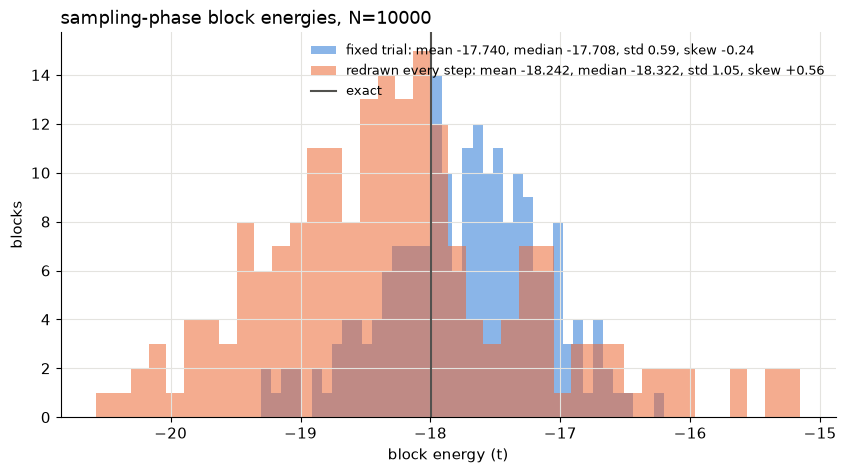

In [19]:
def plot_hist(N, bins=40):
    ax = plt.subplots()[1]
    for m in METHODS:
        r = runs[m, N]
        if "blocks" not in r:
            continue
        b = r["blocks"]
        e = b["e"][1 + b["n_eql"]:]
        d = e - e.mean()
        skew = (d ** 3).mean() / (d ** 2).mean() ** 1.5
        ax.hist(e, bins=bins, color=COLOR[m], alpha=0.55,
                label=f"{LABEL[m]}: mean {e.mean():.3f}, median {np.median(e):.3f}, std {e.std():.2f}, skew {skew:+.2f}")
    ax.axvline(E_EXACT[L], color=INK2, lw=1.5, label="exact")
    ax.set_xlabel("block energy (t)")
    ax.set_ylabel("blocks")
    ax.set_title(f"sampling-phase block energies, N={N}", loc="left")
    ax.legend(frameon=False, fontsize=9)
    return ax


plot_hist(10000);

## Total walker weight per block

The total weight at the end of each block, before reconfiguration resets it to the number of walkers (200). The redrawn trial loses weight every block; the fixed one does not.

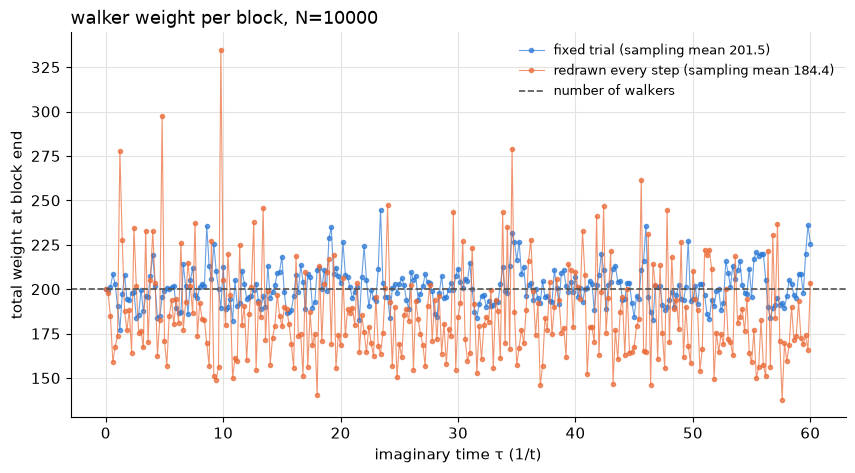

In [20]:
def plot_weights(N):
    ax = plt.subplots()[1]
    for m in METHODS:
        r = runs[m, N]
        if "blocks" in r:
            w = r["blocks"]["w"]
            ax.plot(np.arange(len(w)) * TAU_BLOCK, w, "-o", ms=3, lw=0.8, color=COLOR[m], alpha=0.7,
                    label=f"{LABEL[m]} (sampling mean {w[1 + r['blocks']['n_eql']:].mean():.1f})")
    ax.axhline(200, color=INK2, lw=1.2, ls="--", label="number of walkers")
    ax.set_xlabel("imaginary time τ (1/t)")
    ax.set_ylabel("total weight at block end")
    ax.set_title(f"walker weight per block, N={N}", loc="left")
    ax.legend(frameon=False, fontsize=9)
    return ax


plot_weights(10000);

## Validation: L=8 with a χ=4 trial

Here the exact energy is known from FCI and a χ=4 DMRG trial is poor, so the fixed trial's truncation bias should appear at small L. The redrawn trial should stay within its error bars. N = 1000, 2000 and 5000; the other settings are as above.

In [21]:
L8, CHI8, NS8 = 8, 4, [1000, 2000, 5000]
runs8 = {(m, N): get_run(m, N, results, L=L8, chi=CHI8, log=DATA / f"{m}_L{L8}_chi{CHI8}_N{N}.log")
         for m in METHODS for N in NS8}
E_TRIAL8 = next((r["e_dmrg_trial"] for k, r in results.items() if k[0] == L8 and k[2] == CHI8), np.nan)
print(f"chi={CHI8} trial energy at L={L8}: {E_TRIAL8:.6f}, exact {E_EXACT[L8]:.6f}\n")
print(f"{'N':>6}  {'method':10s} {'E':>11s} {'err':>7s} {'E - exact':>10s} {'z':>6s} {'t_run [s]':>9s}  status")
for N in NS8:
    for m in METHODS:
        r = runs8[m, N]
        if "e" not in r:
            print(f"{N:>6}  {m:10s} {'':>47s}  not finished")
            continue
        bias = r["e"] - E_EXACT[L8]
        status = "done" if r["finished"] else f"running: {r['sampled']}/200 sampling blocks"
        t_run = f"{r['t_run']:9.0f}" if r["finished"] else " " * 9
        print(f"{N:>6}  {m:10s} {r['e']:11.5f} {r['err']:7.4f} {bias:+10.4f} {bias / r['err']:+6.1f} {t_run}  {status}")

chi=4 trial energy at L=8: -4.016960, exact -4.235807

     N  method               E     err  E - exact      z t_run [s]  status
  1000  fixed         -4.20460  0.0067    +0.0312   +4.7        52  done
  1000  resampled     -4.22276  0.0128    +0.0130   +1.0       130  done
  2000  fixed         -4.19853  0.0083    +0.0373   +4.5        60  done
  2000  resampled     -4.21709  0.0075    +0.0187   +2.5       183  done
  5000  fixed         -4.20231  0.0085    +0.0335   +3.9        72  done
  5000  resampled     -4.19987  0.0079    +0.0359   +4.5       303  done


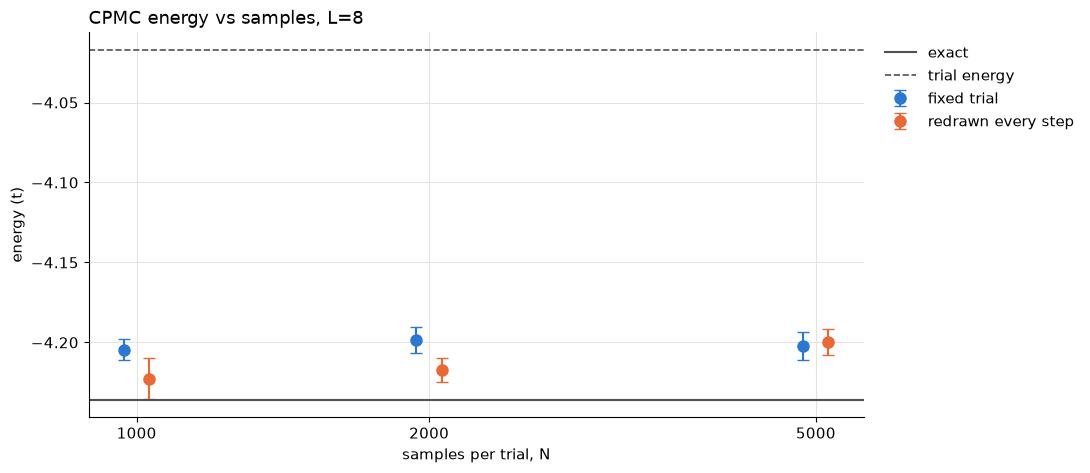

In [22]:
plot_vs_N(runs=runs8, ns=NS8, L=L8, e_trial=E_TRIAL8);

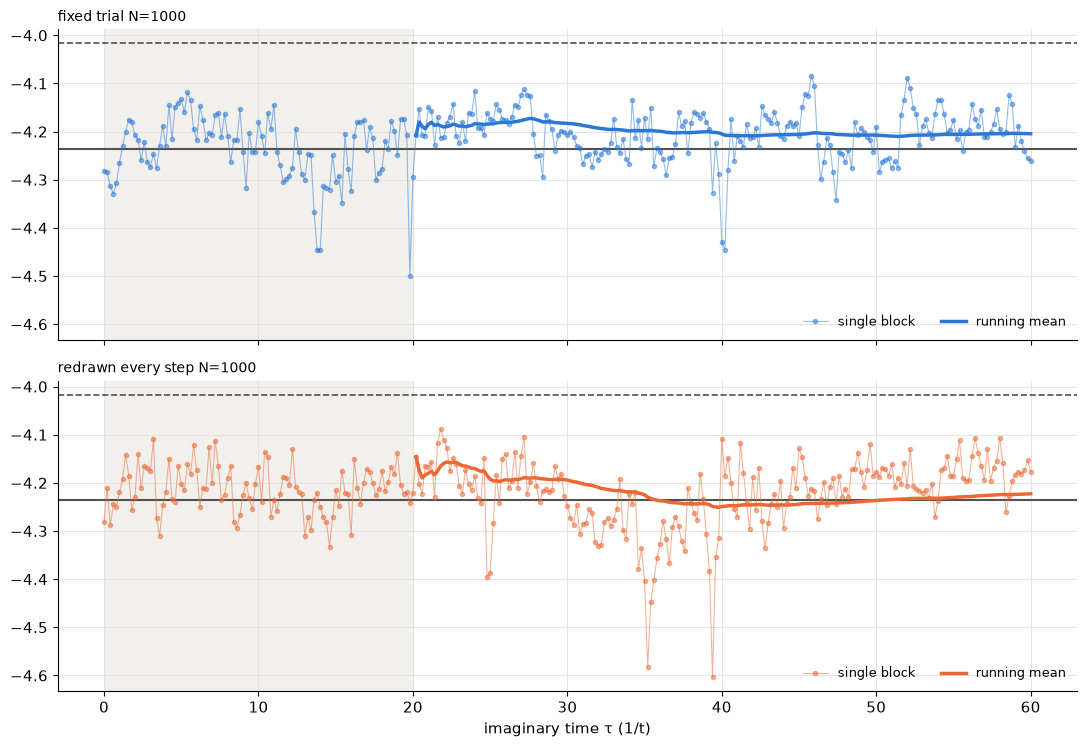

In [23]:
plot_blocks(1000, runs=runs8, L=L8, e_trial=E_TRIAL8);

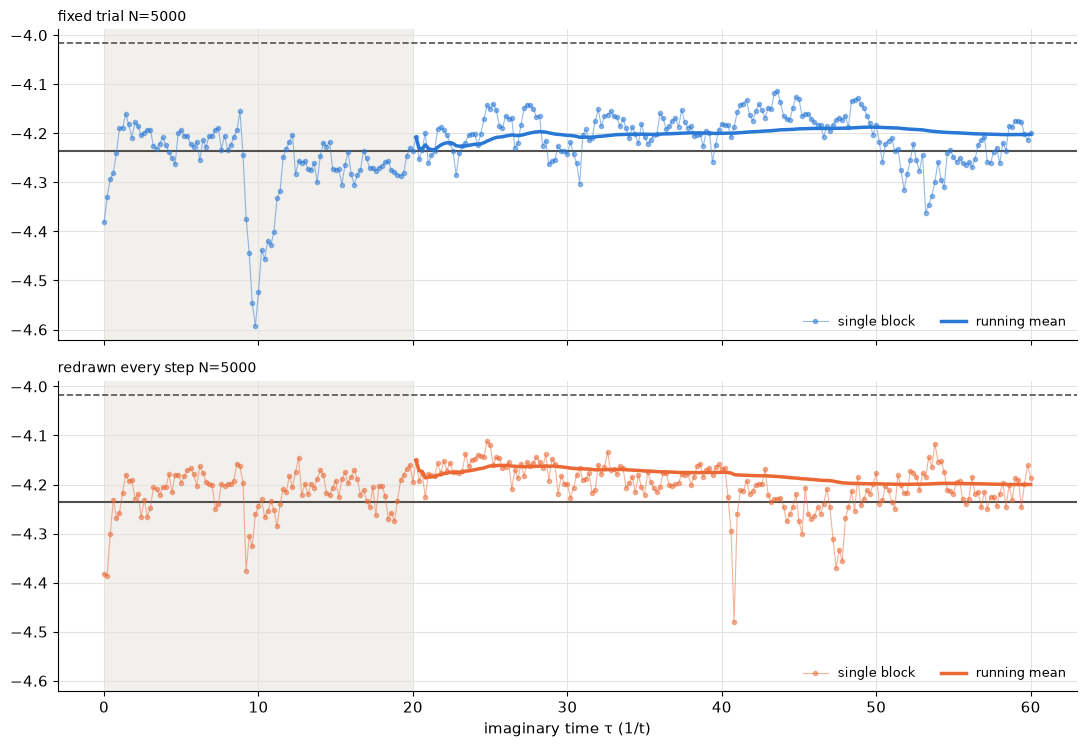

In [24]:
plot_blocks(5000, runs=runs8, L=L8, e_trial=E_TRIAL8);

### L=8, χ=4 averaged over 10 seeds

Seed index $s$ shifts both the CPMC seed (1234 + $s$) and the sampling seed (1 + $s$); $s=0$ are the runs above. For each (N, method) the table gives the mean over seeds and its standard error from the seed-to-seed spread. It also gives the spread itself next to the mean of the runs' own blocking errors: if those errors are honest, the two should be about equal.

In [25]:
seed_runs = {}
for r in map(json.loads, open(DATA / "results.jsonl")):
    if r["L"] == L8 and r.get("chi") == CHI8 and r.get("e_cpmc") is not None:
        seed_runs.setdefault((r["method"], r["N"]), {})[r.get("seed", 0)] = (r["e_cpmc"], r["err_cpmc"])

print(f"{'N':>6}  {'method':10s} {'seeds':>5} {'mean E':>10} {'SE (spread)':>11} {'E - exact':>10} {'z':>6}"
      f" {'seed spread':>11} {'mean run err':>12}")
seed_avg = {}
for N in NS8:
    for m in METHODS:
        v = seed_runs.get((m, N), {})
        if not v:
            continue
        e = np.array([x[0] for x in v.values()]); err = np.array([x[1] for x in v.values()])
        mean, spread = e.mean(), e.std(ddof=1) if len(e) > 1 else np.nan
        se = spread / np.sqrt(len(e))
        seed_avg[m, N] = (mean, se, e)
        bias = mean - E_EXACT[L8]
        print(f"{N:>6}  {m:10s} {len(e):>5} {mean:10.5f} {se:11.5f} {bias:+10.4f} {bias / se:+6.1f}"
              f" {spread:11.4f} {err.mean():12.4f}")

     N  method     seeds     mean E SE (spread)  E - exact      z seed spread mean run err
  1000  fixed         10   -4.20743     0.00546    +0.0284   +5.2      0.0173       0.0087
  1000  resampled     10   -4.21860     0.00550    +0.0172   +3.1      0.0174       0.0106
  2000  fixed         10   -4.21125     0.00497    +0.0246   +4.9      0.0157       0.0083
  2000  resampled     10   -4.21783     0.00358    +0.0180   +5.0      0.0113       0.0080
  5000  fixed         10   -4.22334     0.00613    +0.0125   +2.0      0.0194       0.0101
  5000  resampled     10   -4.20533     0.00431    +0.0305   +7.1      0.0136       0.0064


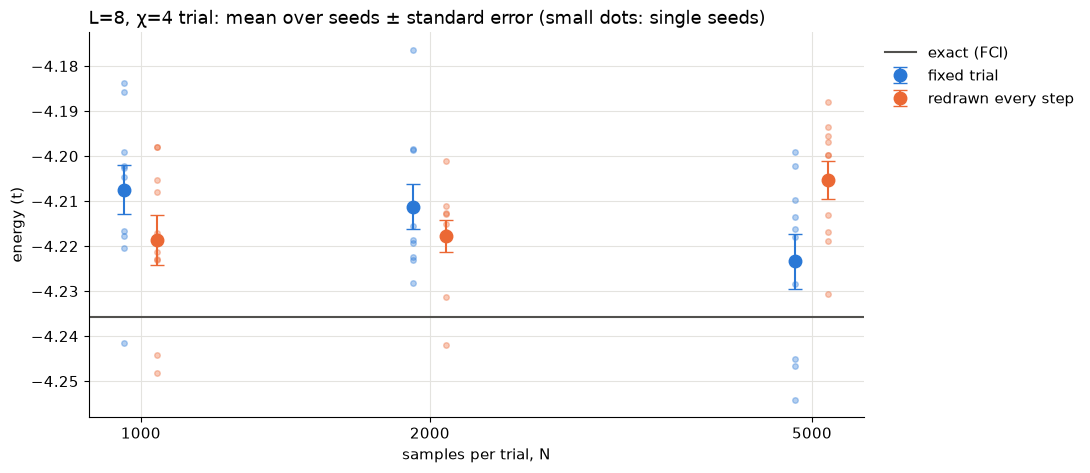

In [26]:
def plot_seed_avg(ax=None):
    ax = ax or plt.subplots()[1]
    for k, m in enumerate(METHODS):
        for N in NS8:
            if (m, N) not in seed_avg:
                continue
            mean, se, e = seed_avg[m, N]
            x = N * (1 + 0.04 * (2 * k - 1))
            ax.plot(np.full(len(e), x), e, "o", ms=4, color=COLOR[m], alpha=0.35)       # single seeds
            ax.errorbar(x, mean, se, fmt="o", ms=9, color=COLOR[m], capsize=5,
                        label=LABEL[m] if N == NS8[0] else None)
    ax.axhline(E_EXACT[L8], color=INK2, lw=1.5, label="exact (FCI)")
    ax.set_xscale("log")
    ax.minorticks_off()
    ax.set_xticks(NS8, [str(N) for N in NS8])
    ax.set_xlabel("samples per trial, N")
    ax.set_ylabel("energy (t)")
    ax.set_title(f"L={L8}, χ={CHI8} trial: mean over seeds ± standard error (small dots: single seeds)", loc="left")
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
    return ax


plot_seed_avg();